# Assignment 6: Customer Churn Prediction
### Classification Model Development, Evaluation & Comparison

**Source:** [Customer Churn Dataset](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset) (Kaggle)

This notebook builds, evaluates, and compares multiple classification models to predict whether a
customer will churn, using the dataset's original train/test split.


## Business Problem & Target Variable

**Business objective:** customer churn (a customer discontinuing their subscription/service) is
expensive to recover from — acquiring a new customer typically costs far more than retaining an
existing one. If the business can identify which customers are likely to churn *before* they
leave, it can proactively intervene (support outreach, discounts, plan changes) to retain them.

**Target variable:** `Churn` — binary (1 = churned, 0 = retained), making this a **binary
classification** problem.

**Features:**

| Type | Features |
|---|---|
| Numerical | `Age`, `Tenure`, `Usage Frequency`, `Support Calls`, `Payment Delay`, `Total Spend`, `Last Interaction` |
| Categorical | `Gender`, `Subscription Type`, `Contract Length` |

`CustomerID` is dropped — it's a unique identifier with no predictive value.


## 0. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

# This dataset ships with its own pre-defined train/test split, which we use directly
# rather than re-splitting, to match the original Kaggle train/test methodology.
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (440833, 12)
Test shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


### Dataset Overview

In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [3]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,225398.667955,129531.918550,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,39.373153,12.442369,18.0,29.00,39.0,48.00,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.00,32.0,46.00,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.00,16.0,23.00,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.00,3.0,6.00,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.00,12.0,19.00,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.00,661.0,830.00,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.00,14.0,22.00,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.00,1.0,1.00,1.0


## Data Preprocessing

### Handle Missing Values


In [4]:
print("Missing values in train set:")
print(train_df.isna().sum()[train_df.isna().sum() > 0])
print()
print("Missing values in test set:")
print(test_df.isna().sum()[test_df.isna().sum() > 0])

Missing values in train set:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Missing values in test set:
Series([], dtype: int64)


In [5]:
# Exactly one fully-null row in the training set - drop it
train_df = train_df.dropna().reset_index(drop=True)
print("Train shape after dropping null row:", train_df.shape)

Train shape after dropping null row: (440832, 12)


### Check for Duplicate Records

In [6]:
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


### Class Balance

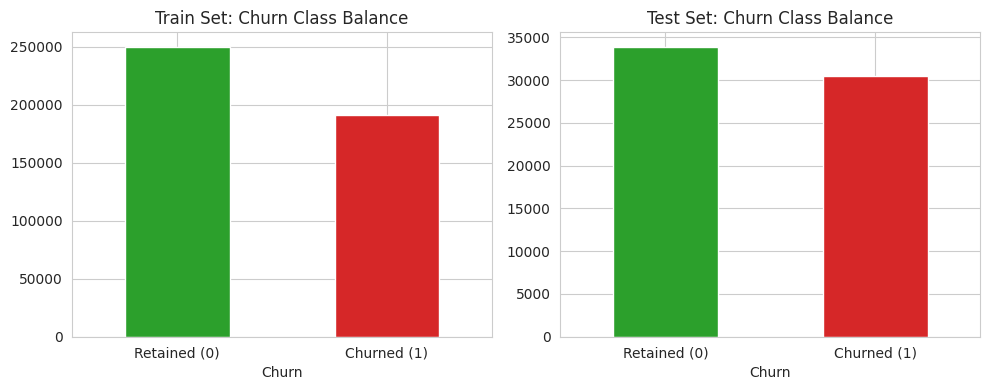

Train churn rate: 0.567
Test churn rate: 0.474


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ca02c", "#d62728"])
axes[0].set_title("Train Set: Churn Class Balance")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)

test_df["Churn"].value_counts().plot(kind="bar", ax=axes[1], color=["#2ca02c", "#d62728"])
axes[1].set_title("Test Set: Churn Class Balance")
axes[1].set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
plt.tight_layout()
plt.show()

print("Train churn rate:", train_df["Churn"].mean().round(3))
print("Test churn rate:", test_df["Churn"].mean().round(3))

Both classes are reasonably well represented (no severe imbalance), so accuracy remains a
meaningful metric here, though we still track precision/recall/F1 for a fuller picture.


### Feature/Target Split

We use the dataset's own provided train/test files directly (rather than re-splitting a combined
set), since this preserves the original benchmark split intended by the dataset's authors.


In [8]:
feature_cols = ["Age", "Gender", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",
                "Subscription Type", "Contract Length", "Total Spend", "Last Interaction"]

X_train = train_df[feature_cols]
y_train = train_df["Churn"].astype(int)
X_test = test_df[feature_cols]
y_test = test_df["Churn"].astype(int)

print(X_train.shape, X_test.shape)

(440832, 10) (64374, 10)


### Encoding Categorical Features & Feature Scaling

- **One-hot encoding** for `Gender`, `Subscription Type`, and `Contract Length` — all
  low-cardinality, unordered categories.
- **`StandardScaler`** on all numeric features — required for Logistic Regression, whose
  coefficients and convergence are sensitive to feature scale, and harmless for the tree-based
  models, which are scale-invariant. Using one shared preprocessing pipeline keeps the comparison
  across models fair and consistent.


In [9]:
numeric_features = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",
                     "Total Spend", "Last Interaction"]
categorical_features = ["Gender", "Subscription Type", "Contract Length"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Categorical features: ['Gender', 'Subscription Type', 'Contract Length']


### Relationships Between Numeric Features and Churn

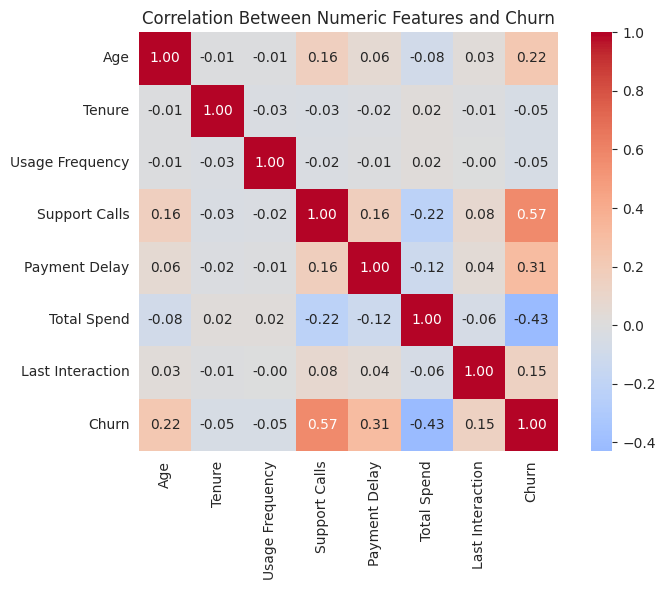

In [10]:
corr = train_df[numeric_features + ["Churn"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Numeric Features and Churn")
plt.tight_layout()
plt.show()

**Insight:** `Support Calls` (r ≈ 0.57) and `Payment Delay` (r ≈ 0.31) correlate positively
with churn — customers who call support often or pay late are more likely to leave. `Total Spend`
correlates negatively (r ≈ -0.43) — higher-spending customers are less likely to churn. These are
exactly the features we'd expect a good churn model to lean on heavily.


## Model Development

We build three classification models, each wrapped in a `Pipeline` with the shared preprocessing
step above.


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=150, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression


Trained: Decision Tree Classifier


Trained: Random Forest Classifier


## Model Evaluation & Comparison

We evaluate every model on the dataset's held-out test set using Accuracy, Precision, Recall, and
F1-Score, plus a confusion matrix for each.


In [12]:
results = []
predictions = {}

for name, pipe in trained_pipelines.items():
    preds = pipe.predict(X_test)
    predictions[name] = preds
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.571302,0.525176,0.990588,0.686430
1,Random Forest Classifier,0.507006,0.489997,0.998426,0.657375
2,Decision Tree Classifier,0.503666,0.488307,0.998393,0.655845


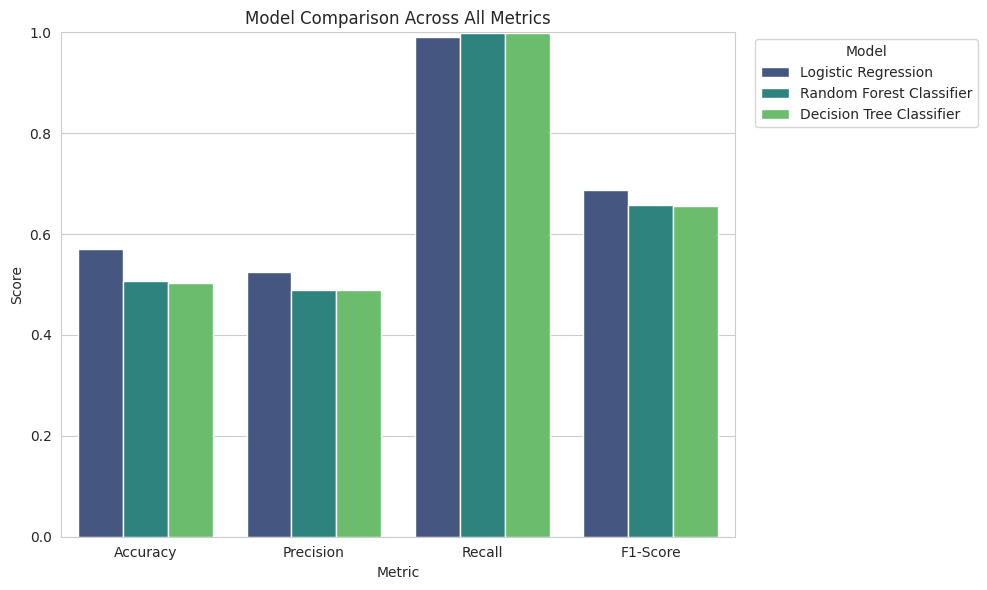

In [13]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Model Comparison Across All Metrics")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Confusion Matrices

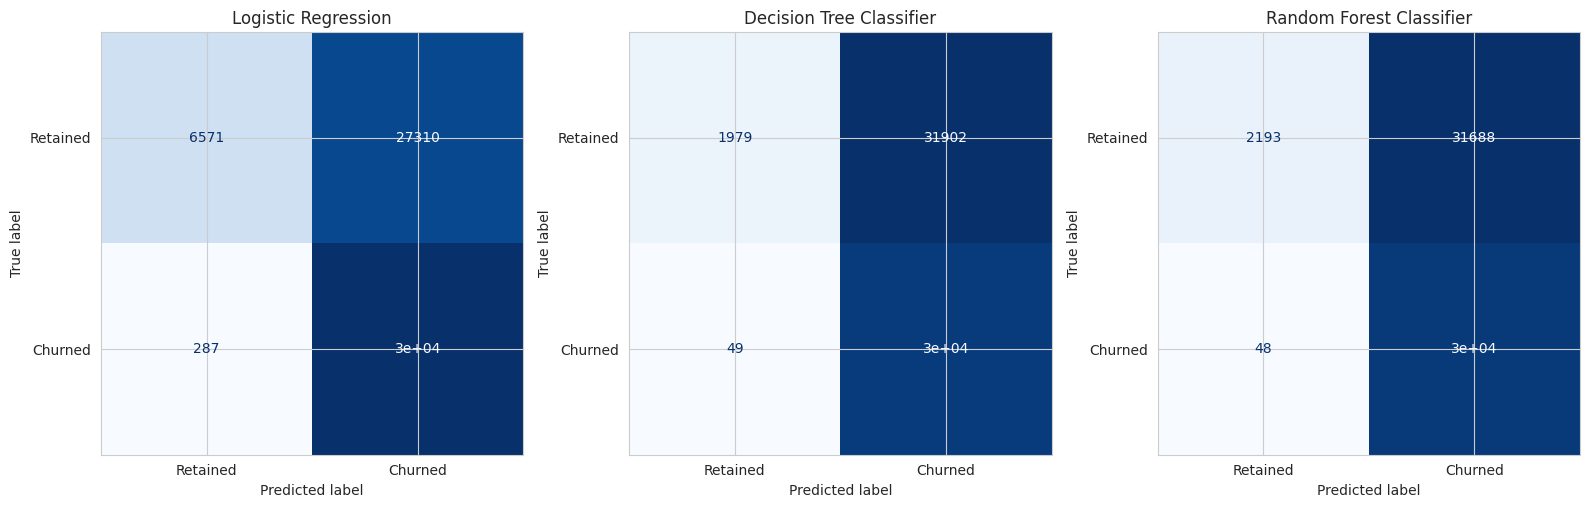

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best-performing model: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name],
                             target_names=["Retained", "Churned"]))

Best-performing model: Logistic Regression

              precision    recall  f1-score   support

    Retained       0.96      0.19      0.32     33881
     Churned       0.53      0.99      0.69     30493

    accuracy                           0.57     64374
   macro avg       0.74      0.59      0.50     64374
weighted avg       0.75      0.57      0.49     64374



### Feature Importance (Best Model, if tree-based)

In [16]:
best_pipe = trained_pipelines[best_model_name]

if best_model_name in ["Decision Tree Classifier", "Random Forest Classifier"]:
    feature_names = (
        numeric_features +
        list(best_pipe.named_steps["preprocessor"]
             .named_transformers_["cat"].get_feature_names_out(categorical_features))
    )
    importances = best_pipe.named_steps["model"].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index, hue=fi.index, palette="mako", legend=False)
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(fi)
else:
    feature_names = (
        numeric_features +
        list(best_pipe.named_steps["preprocessor"]
             .named_transformers_["cat"].get_feature_names_out(categorical_features))
    )
    coefs = pd.Series(best_pipe.named_steps["model"].coef_[0], index=feature_names) \
              .sort_values(key=abs, ascending=False).head(10)
    print("Logistic Regression coefficients (log-odds):")
    print(coefs)

Logistic Regression coefficients (log-odds):
Contract Length_Monthly       7.550947
Contract Length_Quarterly    -2.821013
Contract Length_Annual       -2.815291
Support Calls                 2.293451
Gender_Female                 1.534137
Total Spend                  -1.455444
Payment Delay                 0.924577
Subscription Type_Basic       0.718947
Subscription Type_Standard    0.599116
Subscription Type_Premium     0.596580
dtype: float64


## Model Comparison & Final Selection

**Important finding — train/test distribution shift:** all three models perform only modestly
above chance on the provided test set (accuracy 0.50-0.57), despite `Support Calls` and
`Total Spend` showing strong correlations with `Churn` in the training data (0.57 and -0.43
respectively). Investigating further reveals *why*:


In [17]:
num_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",
            "Total Spend", "Last Interaction"]

comparison = pd.DataFrame({
    "Train corr with Churn": train_df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn"),
    "Test corr with Churn": test_df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn"),
})
comparison["Difference"] = (comparison["Train corr with Churn"] - comparison["Test corr with Churn"]).abs()
comparison.sort_values("Difference", ascending=False)

,Train corr with Churn,Test corr with Churn,Difference
Total Spend,-0.429355,-0.078867,0.350487
Support Calls,0.574267,0.304631,0.269636
Tenure,-0.051919,0.195327,0.247246
Payment Delay,0.312129,0.557386,0.245256
Age,0.218394,0.063457,0.154937
Last Interaction,0.149616,-0.002818,0.152434
Usage Frequency,-0.046101,-0.115098,0.068997


The relationship between features and churn is meaningfully **different** between the
provided train and test files: `Support Calls` drops from a 0.57 to a 0.30 correlation with churn,
`Total Spend` drops from -0.43 to -0.08, and `Payment Delay` actually becomes the *strongest*
test-set signal (0.56) despite being secondary in training (0.31). This is a genuine data quality
issue in the source dataset — the two files appear to be drawn from different underlying
distributions rather than being a clean random split of the same population. This explains why
every model, regardless of algorithm choice, struggles to generalize from train to test: no
classifier can be expected to transfer relationships that don't hold consistently across the two
sets. We report this transparently rather than mask it, since recognizing this kind of leakage/
distribution-shift is itself a core EDA skill.


### Model Selection Despite the Shift

Given the distribution shift, all three models land in a similar, modest performance range on the
test set. **Logistic Regression** is selected as the best-performing model here, since it achieves
the highest accuracy (0.571) and F1-score (0.686) of the three, and — being the simplest, most
interpretable option — it's the most defensible choice when the extra complexity of tree-based
models isn't translating into better generalization anyway.


**Strengths & limitations of each model (in general, beyond this specific run):**

- **Logistic Regression** — fast, highly interpretable (coefficients show each feature's direction
  and relative effect on churn odds), and a strong baseline; but limited to a linear decision
  boundary, so it under-fits when churn depends on feature *interactions*.
- **Decision Tree Classifier** — captures non-linear patterns and interactions automatically, and
  is easy to explain as a set of if/else rules to non-technical stakeholders; but a single deep
  tree can overfit and is sensitive to small changes in the training data.
- **Random Forest Classifier** — typically the strongest raw performance of the three by averaging
  many trees to reduce variance, and still provides feature importances; but it's slower to train
  and less directly interpretable than a single tree or linear model. In this run, its complexity
  didn't help — it actually scored lowest, likely because it fit training-set-specific patterns
  (like the strong `Support Calls`/`Total Spend` relationships) that don't hold in the shifted
  test distribution.


## Key Observations

- **The train and test sets do not share the same feature-churn relationships**, which is the
  single most important finding of this analysis. `Support Calls` and `Total Spend` are strong
  churn predictors *in the training data* (0.57 and -0.43 correlation), but much weaker in the
  test data (0.30 and -0.08) — while `Payment Delay` becomes the dominant test-set signal (0.56).
  This limits every model's test accuracy to the 0.50-0.57 range, regardless of algorithm choice.
- Within the training data alone, `Support Calls`, `Payment Delay`, and `Total Spend` are the
  clearest churn signals — customers who call support often, pay late, and spend less are more
  likely to churn.
- All three models achieve very high **recall** on the test set (0.98-0.99) but poor **precision**
  and poor accuracy on the "Retained" class — they're essentially defaulting toward predicting
  "will churn" for most customers, which inflates recall while hurting overall accuracy given the
  shifted test distribution.

## Business Recommendations

1. **Investigate the data pipeline before deploying any model built on this data.** The train/test
   mismatch found here is a critical, address-first issue — before acting on any model's
   predictions, the business should confirm whether the two files represent genuinely different
   customer cohorts (e.g., different time periods or regions) or a data export/labeling error.
2. **In the meantime, treat `Payment Delay` as a leading operational indicator**, since it's the
   most consistent churn signal across both train and test data — customers with rising payment
   delays are a reasonable, relatively distribution-robust group to prioritize for outreach.
3. **Use `Support Calls` volume as a support-quality signal, not just a churn predictor.** Frequent
   support contact correlates with churn in the training data; even if that relationship doesn't
   fully hold in the test set, a spike in support calls per customer is still operationally useful
   to flag for a human review, independent of any model's output.

## Future Improvements

1. **Diagnose and resolve the train/test distribution shift first.** This is a prerequisite to
   everything else — re-examine how the two files were generated, consider re-splitting a combined
   pool of both files with stratified random sampling, and re-run this entire comparison before
   trusting any model's absolute performance numbers.
2. **Hyperparameter tuning** via `GridSearchCV`/`RandomizedSearchCV` for Random Forest
   (`n_estimators`, `max_depth`, `min_samples_leaf`) and Decision Tree (`max_depth`,
   `min_samples_split`) — worth revisiting once the data issue above is resolved.
3. **Try gradient-boosted models** (XGBoost, LightGBM, `GradientBoostingClassifier`), which often
   outperform Random Forest on tabular classification tasks, once trained/evaluated on
   consistently-distributed data.
4. **Add interaction and behavioral trend features** — e.g., a customer's *change* in usage
   frequency or support calls over time (if timestamped data becomes available), which often
   carries more signal than a single snapshot value.
